In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [4]:
uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings.csv


In [5]:
df = pd.read_csv('hotel_bookings.csv')

df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
df = df.dropna()

In [8]:
X = df.drop(columns=[
    'is_canceled',
    'reservation_status',
    'reservation_status_date'
], errors='ignore')

y = df['is_canceled']

In [9]:
datetime_cols = X.select_dtypes(include=['datetime64']).columns

X = X.drop(columns=datetime_cols)

In [10]:
le = LabelEncoder()

for col in X.select_dtypes(include='object').columns:
    X[col] = le.fit_transform(X[col])

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
lr_model = LogisticRegression(max_iter=5000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=5000)

In [13]:
y_pred = lr_model.predict(X_test)

y_prob = lr_model.predict_proba(X_test)[:,1]

In [14]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9318181818181818


In [15]:
precision = precision_score(y_test, y_pred)

print("Precision:", precision)

Precision: 0.0


In [16]:
recall = recall_score(y_test, y_pred)

print("Recall:", recall)

Recall: 0.0


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.00      0.00      0.00         2

    accuracy                           0.93        44
   macro avg       0.48      0.49      0.48        44
weighted avg       0.91      0.93      0.92        44



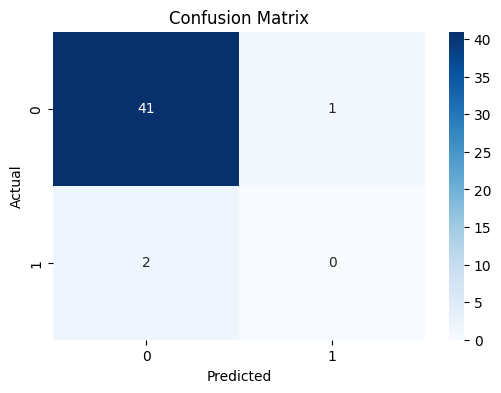

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

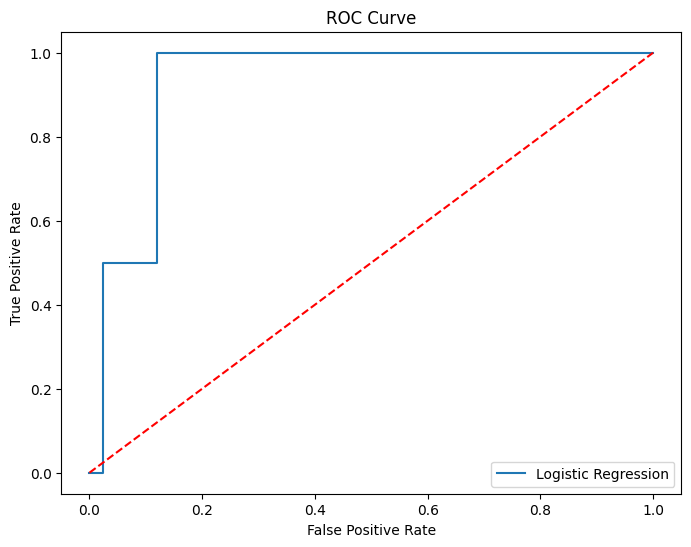

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))

plt.plot(fpr, tpr, label='Logistic Regression')

plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [20]:
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [22]:
dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:,1]

In [23]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9318181818181818


In [24]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.00      0.00      0.00         2

    accuracy                           0.93        44
   macro avg       0.48      0.49      0.48        44
weighted avg       0.91      0.93      0.92        44



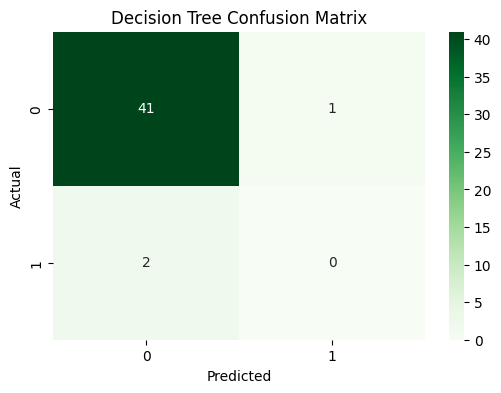

In [25]:
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

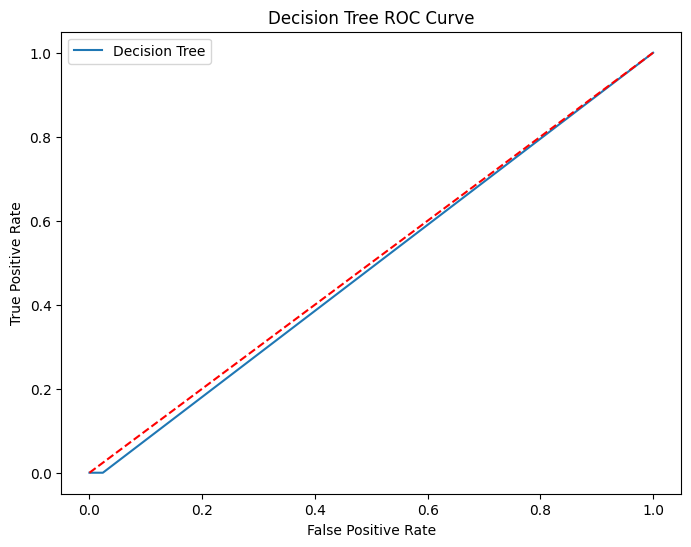

In [26]:
dt_fpr, dt_tpr, thresholds = roc_curve(y_test, dt_prob)

plt.figure(figsize=(8,6))

plt.plot(dt_fpr, dt_tpr, label='Decision Tree')

plt.plot([0,1], [0,1], 'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decision Tree ROC Curve")

plt.legend()

plt.show()

In [27]:
print("Logistic Regression Accuracy:", accuracy)

print("Decision Tree Accuracy:", dt_accuracy)

Logistic Regression Accuracy: 0.9318181818181818
Decision Tree Accuracy: 0.9318181818181818


In [28]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance.head(10))

                     Feature  Importance
1                  lead_time    0.311566
12                   country    0.212190
13            market_segment    0.141179
6    stays_in_weekend_nights    0.089217
8                     adults    0.080976
3         arrival_date_month    0.078184
20           booking_changes    0.063727
23                   company    0.022960
4   arrival_date_week_number    0.000000
7       stays_in_week_nights    0.000000


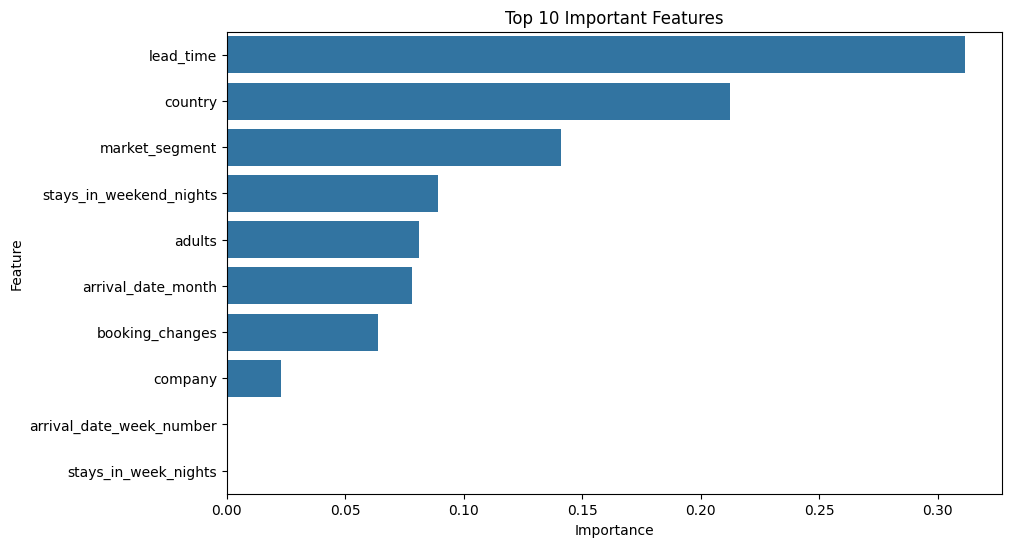

In [29]:
top_features = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()